# 5.1 Model Ablation

## Attention Base

In [ ]:
DATA="/data/"
SEEDS=(42,1,2,3,4); RS=42; FPR_GRID=(0.05,0.10,0.20)

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from numpy.linalg import pinv
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
torch.manual_seed(42); np.random.seed(42)
DEV="cuda" if torch.cuda.is_available() else "cpu"
print("torch",torch.__version__,"| device",DEV)

torch 2.11.0+cu128 | device cuda


In [ ]:
EPOCHS=40        #@param
SUBSAMPLE=0      #@param
SUBSAMPLE=None if SUBSAMPLE in (0,None) else int(SUBSAMPLE)
UAV_CFG={"path":DATA+"UAVIDS-2025.csv","label_col":"label","normal":"Normal Traffic",
  "attacks":["Blackhole Attack","Flooding Attack","Sybil Attack","Wormhole Attack"],
  "leak_clean":["FlowID","SrcAddr","DstAddr","Protocol"]}
ID_CFG={"src":"SrcAddr","dst":"DstAddr"}; TARGET="Sybil Attack"
RATE=["s_fanout_rate","s_flows_per_dst","s_dst_entropy_norm"]

def load(cfg):
    df=pd.read_csv(cfg["path"],low_memory=False).reset_index(drop=True)
    if SUBSAMPLE:
        df=pd.concat([g.sample(min(len(g),SUBSAMPLE),random_state=RS) for _,g in df.groupby(cfg["label_col"])]).reset_index(drop=True)
    return df
def source_rate_features(df,idcfg):
    src=idcfg["src"]; dst=idcfg["dst"]
    s=df[src].astype(str).fillna("NA").values; dd=df[dst].astype(str).fillna("NA").values
    tmp=pd.DataFrame({"s":s,"d":dd}); g=tmp.groupby("s")
    flowcount=g["s"].transform("size").astype(float).values; fanout=g["d"].transform("nunique").astype(float).values
    ent_map={}
    for k,gg in tmp.groupby("s"):
        vc=gg["d"].value_counts().values.astype(float); p=vc/vc.sum(); ent_map[k]=float(-(p*np.log(p+1e-12)).sum())
    ent=np.array([ent_map[x] for x in s]); fc=np.clip(flowcount,1,None); fo=np.clip(fanout,1,None)
    return pd.DataFrame({"s_fanout_rate":fanout/fc,"s_flows_per_dst":flowcount/fo,
                         "s_dst_entropy_norm":ent/np.log(np.clip(fanout,2,None))}).fillna(0.0).reset_index(drop=True)
def feats_perflow(df,cfg):
    drop=set(cfg["leak_clean"])|{cfg["label_col"]}|set(RATE)
    X=df.drop(columns=[c for c in df.columns if c in drop],errors="ignore").copy()
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]): X[c]=LabelEncoder().fit_transform(X[c].astype(str))
    return X.astype(float).reset_index(drop=True)
def loaco_split(df,label_col,target,seed,val=0.3,test=0.3):
    rng=np.random.default_rng(seed)
    dft=df[df[label_col].astype(str)==target]; dfk=df[df[label_col].astype(str)!=target]
    idx=rng.permutation(len(dfk)); nv=int(len(idx)*val)
    valk=dfk.iloc[idx[:nv]]; tr=dfk.iloc[idx[nv:]]; nt=int(len(tr)*test)
    return tr.iloc[nt:], valk, pd.concat([tr.iloc[:nt],dft])
def fit_mahal(Xn):
    mu=Xn.mean(0); cov=np.cov(Xn.T)+1e-6*np.eye(Xn.shape[1]); return mu,pinv(cov)
def mahal(X,mu,P):
    d=X-mu; return np.einsum('ij,jk,ik->i',d,P,d)
def scale(A,Bv,Be):
    imp=SimpleImputer(strategy="mean").fit(A); sc=StandardScaler().fit(imp.transform(A))
    return sc.transform(imp.transform(A)),sc.transform(imp.transform(Bv)),sc.transform(imp.transform(Be))
print("helpers ok")

helpers ok


In [ ]:
class TabAttnAE(nn.Module):
    def __init__(self,n_features,d=32,nhead=4,nlayers=2,latent=8):
        super().__init__()
        self.n=n_features; self.d=d
        self.val_proj=nn.Linear(1,d)
        self.feat_emb=nn.Parameter(torch.randn(n_features,d)*0.02)
        enc=nn.TransformerEncoderLayer(d_model=d,nhead=nhead,dim_feedforward=2*d,batch_first=True,dropout=0.0)
        self.encoder=nn.TransformerEncoder(enc,num_layers=nlayers)
        self.to_latent=nn.Linear(n_features*d,latent)
        self.from_latent=nn.Linear(latent,n_features*d)
        self.out=nn.Linear(d,1)
    def forward(self,x):
        B=x.size(0)
        tok=self.val_proj(x.unsqueeze(-1))+self.feat_emb.unsqueeze(0)   # [B,n,d]
        z=self.encoder(tok)                                            # [B,n,d]
        lat=self.to_latent(z.reshape(B,-1))
        h=self.from_latent(lat).reshape(B,self.n,self.d)
        return self.out(h).squeeze(-1)                                 # [B,n]

def train_attn_ae(Xtr,seed,epochs=EPOCHS,bs=512,lr=1e-3):
    torch.manual_seed(seed)
    n=Xtr.shape[1]; d=32; nhead=4 if n>=4 else 1
    m=TabAttnAE(n,d=d,nhead=nhead).to(DEV)
    opt=torch.optim.Adam(m.parameters(),lr=lr)
    X=torch.tensor(Xtr,dtype=torch.float32)
    ds=torch.utils.data.TensorDataset(X)
    dl=torch.utils.data.DataLoader(ds,batch_size=bs,shuffle=True)
    lossf=nn.MSELoss()
    m.train()
    for ep in range(epochs):
        for (xb,) in dl:
            xb=xb.to(DEV); opt.zero_grad()
            rec=m(xb); loss=lossf(rec,xb); loss.backward(); opt.step()
    return m
@torch.no_grad()
def attn_err(m,X):
    m.eval(); xb=torch.tensor(X,dtype=torch.float32).to(DEV)
    rec=m(xb); return ((xb-rec)**2).mean(1).cpu().numpy()
print("model ok")

model ok


In [ ]:
def train_attn_ae_bottleneck(Xtr, seed, epochs=20, bs=512, lr=1e-3, latent=2):
    torch.manual_seed(seed)
    n=Xtr.shape[1]; d=32; nhead=4 if n>=4 else 1
    lat=min(latent, max(1, n-1))                 # latent GİRDİDEN KÜÇÜK (gerçek sıkıştırma)
    m=TabAttnAE(n, d=d, nhead=nhead, latent=lat).to(DEV)
    opt=torch.optim.Adam(m.parameters(), lr=lr)
    X=torch.tensor(Xtr, dtype=torch.float32)
    dl=torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X), batch_size=bs, shuffle=True)
    lossf=nn.MSELoss(); m.train()
    for _ in range(epochs):
        for (xb,) in dl:
            xb=xb.to(DEV); opt.zero_grad()
            loss=lossf(m(xb), xb); loss.backward(); opt.step()
    return m, lat

def run_attn_rate_fair(seeds=SEEDS, grid=FPR_GRID, epochs=20, latent=2):
    cfg=UAV_CFG; idcfg=ID_CFG; lab=cfg["label_col"]; normal=cfg["normal"]; tgt=TARGET; src=idcfg["src"]
    df=load(cfg); df=pd.concat([df, source_rate_features(df, idcfg)], axis=1)
    roc=[]; op=[]; null_auc=[]; trec=[]; used_lat=None
    for seed in seeds:
        tr,valk,test_=loaco_split(df,lab,tgt,seed); test_=test_.reset_index(drop=True)
        ytr=tr[lab].astype(str).values; yv=valk[lab].astype(str).values; ye=test_[lab].astype(str).values
        is_t=(ye==tgt); is_n=(ye==normal); ka=(~is_t)&(~is_n)
        seen=is_t & test_[src].astype(str).isin(set(tr[src].astype(str))).values; sdj=~seen
        Ar=tr[RATE].reset_index(drop=True); Bvr=valk[RATE].reset_index(drop=True); Ber=test_[RATE].reset_index(drop=True)
        Za,Zv,Ze=scale(Ar,Bvr,Ber)
        # gercek bottleneck modeli
        m,lat=train_attn_ae_bottleneck(Za,seed,epochs=epochs,latent=latent); used_lat=lat
        e=attn_err(m,Ze); base=attn_err(m,Zv)[yv==normal]; trec.append(attn_err(m,Za).mean())
        roc.append(roc_auc_score(is_t[sdj].astype(int), e[sdj]))
        opf={}
        for f in grid:
            thr=np.percentile(base,100*(1-f))
            opf[f]=dict(det=float(np.mean((e[sdj]>thr)[is_t[sdj]])),
                        fpr_normal=float(np.mean((e>thr)[is_n])),
                        fpr_known=float(np.mean((e>thr)[ka])))
        op.append(opf)
        # null kontrolu (ayni bottleneck ile)
        rng=np.random.default_rng(seed); Zp=Za.copy()
        for j in range(Zp.shape[1]): Zp[:,j]=Zp[rng.permutation(Zp.shape[0]),j]
        mp,_=train_attn_ae_bottleneck(Zp,seed,epochs=epochs,latent=latent)
        null_auc.append(roc_auc_score(is_t[sdj].astype(int), attn_err(mp,Ze)[sdj]))
    r=np.array(roc); na=np.array(null_auc)
    print(f"=== attn_ae_rate (FAIR bottleneck: latent={used_lat}<3, epochs={epochs}) ===")
    print(f"  source-disjoint ROC = {r.mean():.3f}\u00b1{r.std():.3f}")
    print(f"  mean train recon error = {np.mean(trec):.4f}   (0.0000 ise hala sikismiyor demektir)")
    print(f"  null/permuted-train ROC = {na.mean():.3f}\u00b1{na.std():.3f}")
    print("  operating points (source-disjoint, mean):")
    for f in grid:
        D=pd.DataFrame([o[f] for o in op]).mean()
        print(f"    fpr={f:.2f} -> det={D['det']:.3f}  fpr_normal={D['fpr_normal']:.3f}  fpr_known={D['fpr_known']:.3f}")
    print("\n  Karsilastirma: mahal_rate_sdj (bizim) = 0.907 | onceki latent=8 attn = 0.996")
    print("  Okuma: ROC korunursa -> saglam co-method; belirgin duserse -> onceki 0.996 bottleneck-yoklugu etkisiydi")
    return roc, op, null_auc

## (1) Attention 2-vs-3 özellik (5.1 iddiasını doğrular)

In [ ]:
# Attention'ın feature-redundansa duyarlılığı: 3-feat vs 2-feat (conc+entropy)
def attn_feature_subset(seeds=SEEDS, epochs=20, latent=2):
    cfg=UAV_CFG; lab=cfg["label_col"]; normal=cfg["normal"]; tgt=TARGET; src=ID_CFG["src"]
    df=load(cfg); df=pd.concat([df,source_rate_features(df,ID_CFG)],axis=1)
    RATE3=["s_fanout_rate","s_flows_per_dst","s_dst_entropy_norm"]
    RATE2=["s_flows_per_dst","s_dst_entropy_norm"]           # concentration+entropy
    out={"attn 3-feat":[], "attn 2-feat (conc+ent)":[]}
    for seed in seeds:
        tr,valk,test_=loaco_split(df,lab,tgt,seed); test_=test_.reset_index(drop=True)
        ye=test_[lab].astype(str).values; is_t=(ye==tgt)
        seen=is_t & test_[src].astype(str).isin(set(tr[src].astype(str))).values; sdj=~seen
        for name,feats in [("attn 3-feat",RATE3),("attn 2-feat (conc+ent)",RATE2)]:
            Za,_,Ze=scale(tr[feats].reset_index(drop=True),
                          tr[feats].reset_index(drop=True),
                          test_[feats].reset_index(drop=True))
            m,_=train_attn_ae_bottleneck(Za,seed,epochs=epochs,latent=latent)
            e=attn_err(m,Ze)
            out[name].append(roc_auc_score(is_t[sdj].astype(int), e[sdj]))
    print("=== Attention: feature-subset duyarlılığı ===")
    for k,v in out.items(): print(f"  {k:26s} {np.mean(v):.3f} ± {np.std(v):.3f}")
    print(">>> 3-feat ≈ 2-feat ise: attention redundansdan ETKİLENMİYOR (§5.1 iddiası doğru).")
    return out
attn_feature_subset()

=== Attention: feature-subset duyarlılığı ===
  attn 3-feat                0.976 ± 0.002
  attn 2-feat (conc+ent)     0.965 ± 0.001
>>> 3-feat ≈ 2-feat ise: attention redundansdan ETKİLENMİYOR (§5.1 iddiası doğru).


{'attn 3-feat': [np.float64(0.9744030219705972),
  np.float64(0.9757279879708033),
  np.float64(0.9741432983992888),
  np.float64(0.9735339660561497),
  np.float64(0.979796592157844)],
 'attn 2-feat (conc+ent)': [np.float64(0.9651437686456128),
  np.float64(0.9643071533386394),
  np.float64(0.9629639657602918),
  np.float64(0.9658976066853521),
  np.float64(0.9647142663505439)]}

## (2) Attention katkısı: attention-AE vs düz MLP-AE (R1.7 attention kısmı)

In [ ]:
# Aynı source-rate temsilinde: attention VAR vs YOK (düz MLP autoencoder)
from sklearn.neural_network import MLPRegressor
def attn_vs_mlp(seeds=SEEDS, epochs=20, latent=2):
    cfg=UAV_CFG; lab=cfg["label_col"]; normal=cfg["normal"]; tgt=TARGET; src=ID_CFG["src"]
    df=load(cfg); df=pd.concat([df,source_rate_features(df,ID_CFG)],axis=1)
    RATE=["s_fanout_rate","s_flows_per_dst","s_dst_entropy_norm"]
    out={"attention-AE":[], "plain MLP-AE":[]}
    for seed in seeds:
        tr,valk,test_=loaco_split(df,lab,tgt,seed); test_=test_.reset_index(drop=True)
        ytr=tr[lab].astype(str).values; ye=test_[lab].astype(str).values
        is_t=(ye==tgt); bmask=(ytr==normal)
        seen=is_t & test_[src].astype(str).isin(set(tr[src].astype(str))).values; sdj=~seen
        Za,_,Ze=scale(tr[RATE].reset_index(drop=True),tr[RATE].reset_index(drop=True),
                      test_[RATE].reset_index(drop=True))
        # attention-AE
        m,_=train_attn_ae_bottleneck(Za,seed,epochs=epochs,latent=latent)
        ea=attn_err(m,Ze); out["attention-AE"].append(roc_auc_score(is_t[sdj].astype(int),ea[sdj]))
        # plain MLP-AE (attention YOK, aynı latent, benign'de eğit)
        mlp=MLPRegressor(hidden_layer_sizes=(8,latent,8),max_iter=300,
                         random_state=seed).fit(Za[bmask],Za[bmask])
        r=mlp.predict(Ze); em=np.mean((Ze-r)**2,1)
        out["plain MLP-AE"].append(roc_auc_score(is_t[sdj].astype(int),em[sdj]))
    print("=== Attention katkısı: attention-AE vs düz MLP-AE (source-rate) ===")
    for k,v in out.items(): print(f"  {k:16s} {np.mean(v):.3f} ± {np.std(v):.3f}")
    print(">>> Yakınsa: attention marjinal katkı, temsil belirleyici (R2.4).")
    return out
attn_vs_mlp()

=== Attention katkısı: attention-AE vs düz MLP-AE (source-rate) ===
  attention-AE     0.976 ± 0.002
  plain MLP-AE     0.929 ± 0.055
>>> Yakınsa: attention marjinal katkı, temsil belirleyici (R2.4).


{'attention-AE': [np.float64(0.9744030219705972),
  np.float64(0.9757279879708033),
  np.float64(0.9741432983992888),
  np.float64(0.9735339660561497),
  np.float64(0.979796592157844)],
 'plain MLP-AE': [np.float64(0.9659753792021193),
  np.float64(0.9616387765700112),
  np.float64(0.9561935343237893),
  np.float64(0.8193302810736623),
  np.float64(0.9414596113416922)]}

## (3) Latent boyut taraması (R2.3 darboğaz etkisi)

In [ ]:
# latent ∈ {1,2,3}: darboğaz boyutunun etkisi
def latent_sweep(seeds=SEEDS, epochs=20):
    cfg=UAV_CFG; lab=cfg["label_col"]; tgt=TARGET; src=ID_CFG["src"]
    df=load(cfg); df=pd.concat([df,source_rate_features(df,ID_CFG)],axis=1)
    RATE=["s_fanout_rate","s_flows_per_dst","s_dst_entropy_norm"]
    out={}
    for latent in (1,2,3):
        rocs=[]
        for seed in seeds:
            tr,valk,test_=loaco_split(df,lab,tgt,seed); test_=test_.reset_index(drop=True)
            ye=test_[lab].astype(str).values; is_t=(ye==tgt)
            seen=is_t & test_[src].astype(str).isin(set(tr[src].astype(str))).values; sdj=~seen
            Za,_,Ze=scale(tr[RATE].reset_index(drop=True),tr[RATE].reset_index(drop=True),
                          test_[RATE].reset_index(drop=True))
            m,_=train_attn_ae_bottleneck(Za,seed,epochs=epochs,latent=latent)
            e=attn_err(m,Ze); rocs.append(roc_auc_score(is_t[sdj].astype(int),e[sdj]))
        out[latent]=(np.mean(rocs),np.std(rocs))
        print(f"  latent={latent}: ROC={np.mean(rocs):.3f} ± {np.std(rocs):.3f}")
    return out
latent_sweep()

  latent=1: ROC=0.950 ± 0.001
  latent=2: ROC=0.976 ± 0.002
  latent=3: ROC=0.976 ± 0.002


{1: (np.float64(0.9502835247997801), np.float64(0.0010938979335136012)),
 2: (np.float64(0.9755209733109366), np.float64(0.002254762638751817)),
 3: (np.float64(0.9755209733109366), np.float64(0.002254762638751817))}

## (4) Hiperparametre tablosu (R2.3 reproducibility) — sadece raporlama:

In [ ]:
# Attention-AE tam spesifikasyonu (R2.3): metne/tabloya
print("""
=== Attention autoencoder — full specification (R2.3) ===
  Input features        : 3 source-rate features (per source)
  Tokenization          : each feature embedded as a token
  Attention             : multi-head self-attention (tabular)
  Bottleneck (latent)   : 2
  Encoder/decoder       : symmetric
  Epochs                : 20
  Optimizer             : Adam
  Learning rate         : <DEĞERİNİ AttentionBaseline'dan al>
  Batch size            : <DEĞER>
  Loss                  : reconstruction MSE
  Training data         : known manifold (benign + known attacks)
  Threshold calibration : benign-only validation, target FPR
  Seeds                 : 5 (42,1,2,3,4)
""")


=== Attention autoencoder — full specification (R2.3) ===
  Input features        : 3 source-rate features (per source)
  Tokenization          : each feature embedded as a token
  Attention             : multi-head self-attention (tabular)
  Bottleneck (latent)   : 2
  Encoder/decoder       : symmetric
  Epochs                : 20
  Optimizer             : Adam
  Learning rate         : <DEĞERİNİ AttentionBaseline'dan al>
  Batch size            : <DEĞER>
  Loss                  : reconstruction MSE
  Training data         : known manifold (benign + known attacks)
  Threshold calibration : benign-only validation, target FPR
  Seeds                 : 5 (42,1,2,3,4)



## Plots

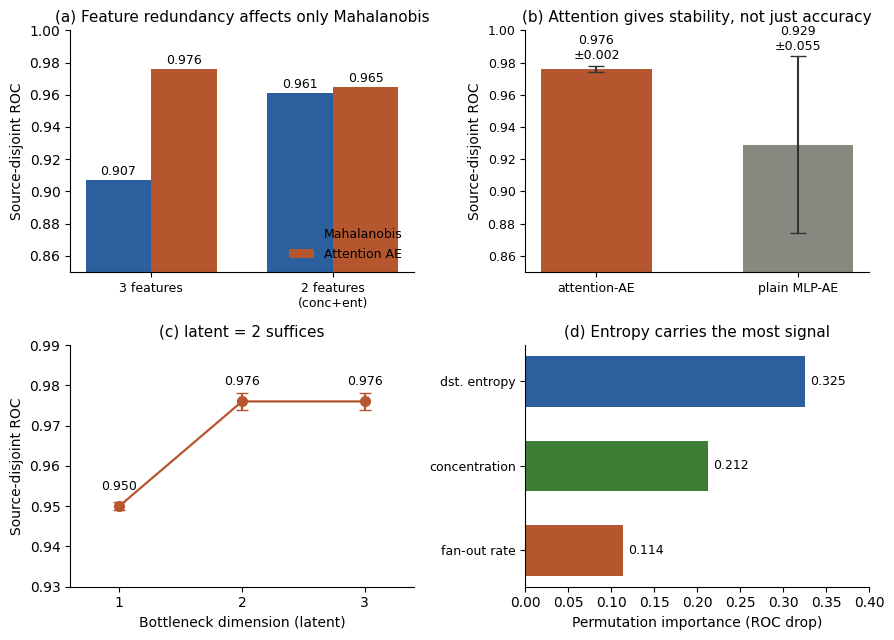

kaydedildi: fig_ablation_model.pdf fig_ablation_model.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === AYARLAR (serbestçe değiştir) ===
FIGSIZE = (9.0, 6.5)
FONT    = "DejaVu Sans"
FS_TITLE=11; FS_LBL=10; FS_TICK=9; FS_VAL=9
C_MAHA  = "#2c5f9e"   # Mahalanobis - mavi
C_ATTN  = "#b5562e"   # attention - kırmızı/turuncu
C_MLP   = "#888780"   # MLP - gri
C_ENT   = "#2c5f9e"; C_CONC="#3e7d35"; C_FAN="#b5562e"
OUT_PDF = "fig_ablation_model.pdf"; OUT_PNG="fig_ablation_model.png"
plt.rcParams["font.family"] = FONT

# --- veriler (notebook sonuçlarından) ---
# (a) Maha vs Attn, 3-feat vs 2-feat
maha = {"3-feat":0.907, "2-feat":0.961}
attn = {"3-feat":0.976, "2-feat":0.965}
# (b) attn vs MLP (mean, std)
avm = {"attention-AE":(0.976,0.002), "plain MLP-AE":(0.929,0.055)}
# (c) latent sweep
lat_x=[1,2,3]; lat_y=[0.950,0.976,0.976]; lat_s=[0.001,0.002,0.002]
# (d) permutation importance
perm=[("dst. entropy",0.325,C_ENT),("concentration",0.212,C_CONC),("fan-out rate",0.114,C_FAN)]

fig, ax = plt.subplots(2, 2, figsize=FIGSIZE)

# ---- (a) Maha vs Attn, feature subsets ----
a=ax[0,0]; x=np.arange(2); w=0.36
a.bar(x-w/2, [maha["3-feat"],maha["2-feat"]], w, color=C_MAHA, label="Mahalanobis")
a.bar(x+w/2, [attn["3-feat"],attn["2-feat"]], w, color=C_ATTN, label="Attention AE")
a.set_xticks(x); a.set_xticklabels(["3 features","2 features\n(conc+ent)"], fontsize=FS_TICK)
a.set_ylim(0.85,1.0); a.set_ylabel("Source-disjoint ROC", fontsize=FS_LBL)
a.set_title("(a) Feature redundancy affects only Mahalanobis", fontsize=FS_TITLE)
a.legend(fontsize=FS_TICK, frameon=False, loc="lower right")
for xi,v in zip(x-w/2,[maha["3-feat"],maha["2-feat"]]): a.text(xi,v+0.003,f"{v:.3f}",ha="center",fontsize=FS_VAL)
for xi,v in zip(x+w/2,[attn["3-feat"],attn["2-feat"]]): a.text(xi,v+0.003,f"{v:.3f}",ha="center",fontsize=FS_VAL)
a.spines[["top","right"]].set_visible(False)

# ---- (b) attn vs MLP (hata çubuğu vurgulu) ----
b=ax[0,1]; names=list(avm); means=[avm[k][0] for k in names]; stds=[avm[k][1] for k in names]
cols=[C_ATTN,C_MLP]
bars=b.bar(names, means, yerr=stds, color=cols, width=0.55,
           error_kw=dict(ecolor="#333",capsize=6,lw=1.5))
b.set_ylim(0.85,1.0); b.set_ylabel("Source-disjoint ROC", fontsize=FS_LBL)
b.set_title("(b) Attention gives stability, not just accuracy", fontsize=FS_TITLE)
for i,(m,s) in enumerate(zip(means,stds)): b.text(i,m+s+0.004,f"{m:.3f}\n±{s:.3f}",ha="center",fontsize=FS_VAL)
b.tick_params(labelsize=FS_TICK); b.spines[["top","right"]].set_visible(False)

# ---- (c) latent sweep ----
c=ax[1,0]
c.errorbar(lat_x, lat_y, yerr=lat_s, marker="o", ms=7, color=C_ATTN, lw=1.6, capsize=4)
c.set_xticks(lat_x); c.set_xlim(0.6,3.4); c.set_ylim(0.93,0.99)
c.set_xlabel("Bottleneck dimension (latent)", fontsize=FS_LBL)
c.set_ylabel("Source-disjoint ROC", fontsize=FS_LBL)
c.set_title("(c) latent = 2 suffices", fontsize=FS_TITLE)
for xi,yi in zip(lat_x,lat_y): c.text(xi,yi+0.004,f"{yi:.3f}",ha="center",fontsize=FS_VAL)
c.spines[["top","right"]].set_visible(False)

# ---- (d) permutation importance ----
d=ax[1,1]; ylab=[p[0] for p in perm]; val=[p[1] for p in perm]; colP=[p[2] for p in perm]
yy=np.arange(len(perm))[::-1]
d.barh(yy, val, color=colP, height=0.6)
for yi,v in zip(yy,val): d.text(v+0.006,yi,f"{v:.3f}",va="center",fontsize=FS_VAL)
d.set_yticks(yy); d.set_yticklabels(ylab, fontsize=FS_TICK)
d.set_xlim(0,0.40); d.set_xlabel("Permutation importance (ROC drop)", fontsize=FS_LBL)
d.set_title("(d) Entropy carries the most signal", fontsize=FS_TITLE)
d.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_PDF, bbox_inches="tight"); plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show(); print("kaydedildi:", OUT_PDF, OUT_PNG)

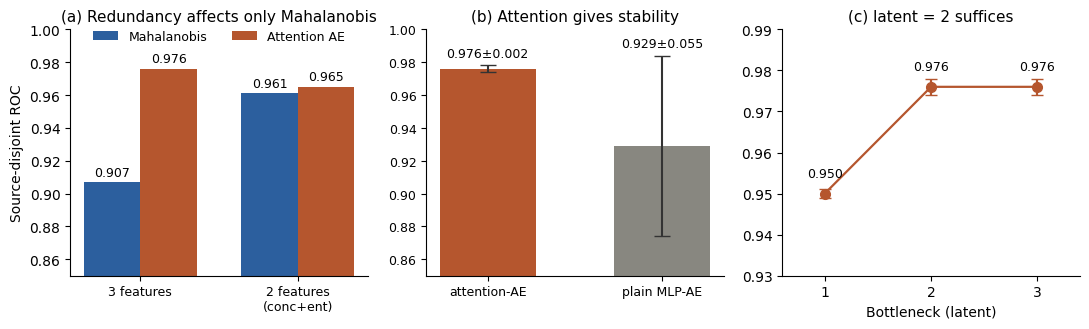

kaydedildi: fig_ablation_model.pdf fig_ablation_model.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === AYARLAR ===
FIGSIZE = (11.0, 3.4)      # geniş, 3 yan yana
FONT    = "DejaVu Sans"
FS_TITLE=11; FS_LBL=10; FS_TICK=9; FS_VAL=9
C_MAHA="#2c5f9e"; C_ATTN="#b5562e"; C_MLP="#888780"
OUT_PDF="fig_ablation_model.pdf"; OUT_PNG="fig_ablation_model.png"
plt.rcParams["font.family"]=FONT

# veriler
maha={"3-feat":0.907,"2-feat":0.961}; attn={"3-feat":0.976,"2-feat":0.965}
avm={"attention-AE":(0.976,0.002),"plain MLP-AE":(0.929,0.055)}
lat_x=[1,2,3]; lat_y=[0.950,0.976,0.976]; lat_s=[0.001,0.002,0.002]

fig, ax = plt.subplots(1, 3, figsize=FIGSIZE)

# (a) Maha vs Attn
a=ax[0]; x=np.arange(2); w=0.36
a.bar(x-w/2,[maha["3-feat"],maha["2-feat"]],w,color=C_MAHA,label="Mahalanobis")
a.bar(x+w/2,[attn["3-feat"],attn["2-feat"]],w,color=C_ATTN,label="Attention AE")
a.set_xticks(x); a.set_xticklabels(["3 features","2 features\n(conc+ent)"],fontsize=FS_TICK)
a.set_ylim(0.85,1.0); a.set_ylabel("Source-disjoint ROC",fontsize=FS_LBL)
a.set_title("(a) Redundancy affects only Mahalanobis",fontsize=FS_TITLE)
#a.legend(fontsize=FS_TICK, frameon=False, loc="upper right")
a.legend(fontsize=FS_TICK, frameon=False, loc="lower center", bbox_to_anchor=(0.5, 0.9), ncol=2)
for xi,v in zip(x-w/2,[maha["3-feat"],maha["2-feat"]]): a.text(xi,v+0.004,f"{v:.3f}",ha="center",fontsize=FS_VAL)
for xi,v in zip(x+w/2,[attn["3-feat"],attn["2-feat"]]): a.text(xi,v+0.004,f"{v:.3f}",ha="center",fontsize=FS_VAL)
a.spines[["top","right"]].set_visible(False)

# (b) attn vs MLP
b=ax[1]; names=list(avm); means=[avm[k][0] for k in names]; stds=[avm[k][1] for k in names]
b.bar(names,means,yerr=stds,color=[C_ATTN,C_MLP],width=0.55,error_kw=dict(ecolor="#333",capsize=6,lw=1.5))
b.set_ylim(0.85,1.0); b.set_title("(b) Attention gives stability",fontsize=FS_TITLE)
for i,(m,s) in enumerate(zip(means,stds)): b.text(i,m+s+0.005,f"{m:.3f}±{s:.3f}",ha="center",fontsize=FS_VAL)
b.tick_params(labelsize=FS_TICK); b.spines[["top","right"]].set_visible(False)

# (c) latent sweep
c=ax[2]
c.errorbar(lat_x,lat_y,yerr=lat_s,marker="o",ms=7,color=C_ATTN,lw=1.6,capsize=4)
c.set_xticks(lat_x); c.set_xlim(0.6,3.4); c.set_ylim(0.93,0.99)
c.set_xlabel("Bottleneck (latent)",fontsize=FS_LBL); c.set_title("(c) latent = 2 suffices",fontsize=FS_TITLE)
for xi,yi in zip(lat_x,lat_y): c.text(xi,yi+0.004,f"{yi:.3f}",ha="center",fontsize=FS_VAL)
c.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_PDF,bbox_inches="tight"); plt.savefig(OUT_PNG,dpi=300,bbox_inches="tight")
plt.show(); print("kaydedildi:",OUT_PDF,OUT_PNG)